In [2]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import synthpop
import pdb
import time

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [3]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name":"ProcessDarkCompactObjects", "remove":False, "ifmr_name":'SukhboldN20',
                                                     "kick_mean_ns":350, "kick_mean_bh":100}, # IFMR + kick velocities
                                {"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"} #{"name":"surot"}
                          )
sp_mod.init_populations()

 53798 - Execution Date: 13-08-2025 14:01:31


################################ Settings #################################
 53815 - # reading default parameters from
 53817 - default_config_file =  /u/mhuston/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 53861 - # read configuration from 
 53863 - config_file = '/u/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 53889 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "synthpopsycle",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 662933566,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,


Then, run the specific sightline you want

In [16]:
t0=time.time()
_ = sp_mod.process_location(-1, -1.2, # first, enter l and b in degrees
                            solid_angle=1e-2, solid_angle_unit='deg^2', # solid angle can be in deg^2 or sr
                            save_data=False) # this prevents synthpop from saving in its default format, it will already be saved via popsycle_post_processing
print(f'Synthpop catalog generated in {np.round((time.time()-t0)/60, 2)} minutes.')



############################# update location #############################
 309645 - # set location to: 
 309647 - l, b = (-1.00 deg, -1.20 deg)
 309648 - # set solid_angle to:
 309653 - solid_angle = 1.000e-02 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 312329 - # From density profile (number density)
 312332 - expected_total_iMass = 4334871.9250
 312334 - expected_total_eMass = 2376527.8581
 312338 - average_iMass_per_star = 0.5739
 312341 - mass_loss_correction = 0.5482
 312345 - n_expected_stars = 7553805.7301
 312349 - # Determine velocities when position are generated 


  0%|          | 0/7557598 [00:00<?, ?it/s]

 470254 - # From Generated Field:
 470257 - generated_stars = 7557598
 470374 - generated_total_iMass = 4340396.3255
 470768 - generated_total_eMass = 2369670.8925
 470946 - det_mass_loss_corr = 0.5460
 481423 - # Done


# Population 1;  halo -----------------------------------------------------
 482161 - # From density profile (number density)
 482166 - expected_total_iMass = 5349.9735
 482168 - expected_total_eMass = 2817.4974
 482170 - average_iMass_per_star = 0.5739
 482172 - mass_loss_correction = 0.5266
 482174 - n_expected_stars = 9322.6885
 482180 - # Determine velocities when position are generated 
 482497 - # From Generated Field:
 482499 - generated_stars = 9350
 482501 - generated_total_iMass = 5295.7628
 482511 - generated_total_eMass = 2825.8480
 482513 - det_mass_loss_corr = 0.5336
 482603 - # Done


# Population 2;  nsd ------------------------------------------------------
 484231 - # From density profile (number density)
 484233 - expected_total_iMass = 20857.1856
 4

  0%|          | 0/490424 [00:00<?, ?it/s]

 577645 - # From Generated Field:
 577646 - generated_stars = 490424
 577661 - generated_total_iMass = 279044.6255
 577695 - generated_total_eMass = 152899.2925
 577709 - det_mass_loss_corr = 0.5479
 578476 - # Done


########################### Combine Populations ###########################
 581473 - Number of stars generated: 8675028 (34 columns)
 581475 - included_columns = ['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase', 'Bessell_U', 'Bessell_B', 'Bessell_V', 'Bessell_R', 'Bessell_I', '2MASS_J', '2MASS_H', '2MASS_Ks']
 626177 - ---------------------------------------------------------------



PopSyCLE formatted output saved in synthpop_output/synthpopsycle_l-1.000_b-1.200_psc.h5
Synthpop catalog generated in 5.28 minutes.


# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [17]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_l-1.000_b-1.200_psc.h5", 
                      output_root2 = 'synthpop_test', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = True, 
                      n_proc = 4)

Working on loop ll, bb =  0 4
Working on loop ll, bb =  1 0
Working on loop ll, bb =  2 0
Working on loop ll, bb =  2 1
Working on loop ll, bb =  3 3
Working on loop ll, bb =  3 4
Working on loop ll, bb =  0 0
Working on loop ll, bb =  0 1
Working on loop ll, bb =  1 3
Working on loop ll, bb =  1 4
Working on loop ll, bb =  3 1
Working on loop ll, bb =  3 2
Working on loop ll, bb =  0 2
Working on loop ll, bb =  0 3
Working on loop ll, bb =  2 2
Working on loop ll, bb =  2 3
Working on loop ll, bb =  4 0
Working on loop ll, bb =  4 1
Working on loop ll, bb =  4 4
Working on loop ll, bb =  1 1
Working on loop ll, bb =  1 2
Working on loop ll, bb =  2 4
Working on loop ll, bb =  3 0
Working on loop ll, bb =  4 2
Working on loop ll, bb =  4 3
Candidate events detected:  1556
calc_events runtime : 437.008438 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [18]:
synthetic.refine_events(input_root = 'synthpop_test', 
                        filter_name = 'I',
                        photometric_system = 'ubv',
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  1227
Candidate events in survey window:  1085
refine_events runtime : 2.823535 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [19]:
t = Table.read('synthpop_test_refined_events_ubv_I_Damineli16.fits')
print(t.colnames)

['zams_mass_L', 'mass_L', 'systemMass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'ubv_U_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'ubv_I_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'isMultiple_L', 'N_companions_L', 'rem_id_L', 'obj_id_L', 'zams_mass_S', 'mass_S', 'systemMass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'ubv_U_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'ubv_I_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'isMultiple_S', 'N_companions_S', 'rem_id_S', 'obj_id_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed']


## Figure out how many events due to BH, NS, WD, star

In [20]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 17
Number of NSs: 12
Number of WDs: 163
Number of stars: 893


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

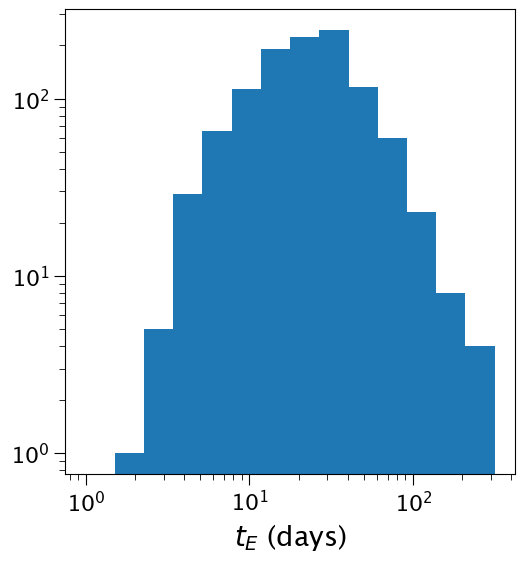

In [21]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

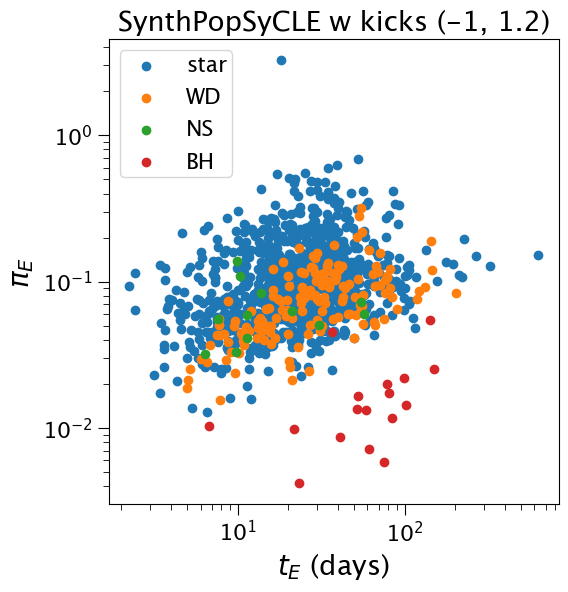

In [24]:
lens_type={0:'star', 101:'WD', 102:'NS', 103:'BH'}
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label=lens_type[rem_id])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend(loc=2)
plt.title('SynthPopSyCLE w kicks (-1, 1.2)')
plt.savefig('synthpopsycle_lenstype.png')

## dL vs dS

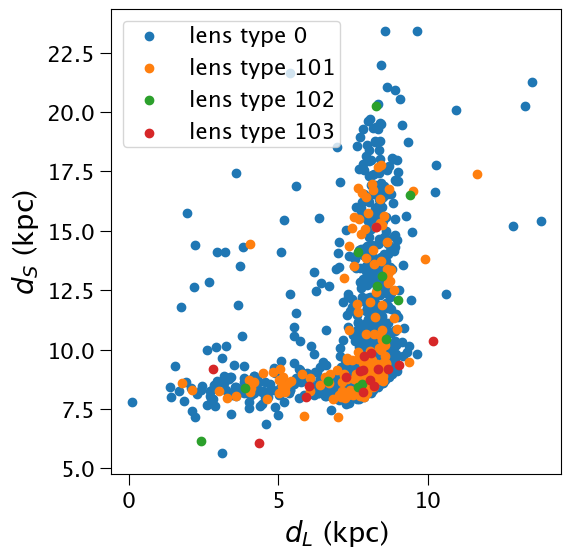

In [23]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()